In [1]:
from envs.stowage_gym import StowageEnv
config_dict = {
    "vessel_shape": (3,5,3),
    "yard_shape": (3,5,3),
    "num_containers": 45,
    "group_num": 3,
    "group_placement": "random",
    "seed": 4307,
    "action_mask": "dict",
}

In [4]:
from torchrl.envs import GymWrapper
from torchrl.envs.transforms import ActionMask, TransformedEnv
import torch
import multiprocessing
from torchrl.envs import (
    Compose,
    StepCounter,
)

is_fork = multiprocessing.get_start_method() == "fork"
device = torch.device(0) if torch.cuda.is_available() and not is_fork else torch.device("cpu")
# device = torch.device("cpu")  # Force CPU for compatibility
env = StowageEnv(config=config_dict)
env = GymWrapper(env, device=device)
masked_env = TransformedEnv(
    env,
    Compose(
        ActionMask(action_key="action", mask_key="mask"),
        StepCounter(),
    ),
)
env=masked_env

In [5]:
num_cells = 64  # number of cells in each layer i.e. output dim.
lr = 3e-4
max_grad_norm = 1.0

frames_per_batch = 450
# For a complete training, bring the number of frames up to 1M
total_frames = 500_00
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sub_batch_size = 128  # cardinality of the sub-samples gathered from the current data in the inner loop
num_epochs = 10  # optimization steps per batch of data collected
clip_epsilon = (
    0.2  # clip value for PPO loss: see the equation in the intro for more context.
)
gamma = 0.99
lmbda = 0.95
entropy_eps = 1e-4

In [10]:
# print("observation_spec:", masked_env.observation_spec)
# print("reward_spec:", masked_env.reward_spec)
# print("input_spec:", masked_env.input_spec)
# print("action_spec (as defined by input_spec):", masked_env.action_spec)

In [11]:
# from torchrl.envs.utils import check_env_specs, ExplorationType
# check_env_specs(masked_env)

In [6]:
import torch.nn as nn
from torchrl.modules import ProbabilisticActor, MaskedOneHotCategorical,ValueOperator, MLP
from tensordict.nn import TensorDictModule

class TypeSafeMLP(nn.Module):
    
    def __init__(self, out_features, num_cells, device=None):
        super().__init__()
        self.mlp = MLP(out_features=out_features, num_cells=num_cells, device=device)
    
    def forward(self, x):
        if x.dtype != torch.float32:
            x = x.float()
        return self.mlp(x)

actor_net = TypeSafeMLP(out_features=env.action_spec.shape[-1], num_cells=[64, 64], device=device)

policy_module = ProbabilisticActor(
    module=TensorDictModule(
        actor_net, 
        in_keys=["observation"], 
        out_keys=["logits"]
    ),
    spec=masked_env.action_spec,
    in_keys=["logits","mask"],
    distribution_class=MaskedOneHotCategorical,
    return_log_prob = True
)

value_net = TypeSafeMLP(out_features=1, num_cells=[64, 64], device=device)
value_module = ValueOperator(
    module=value_net,
    in_keys=["observation"],
)

In [7]:
print("Running policy:", policy_module(env.reset()))
print("Running value:", value_module(env.reset()))
# env.rollout(50,policy_module)

Running policy: TensorDict(
    fields={
        action: Tensor(shape=torch.Size([60]), device=cuda:0, dtype=torch.int64, is_shared=True),
        done: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        logits: Tensor(shape=torch.Size([60]), device=cuda:0, dtype=torch.float32, is_shared=True),
        mask: Tensor(shape=torch.Size([60]), device=cuda:0, dtype=torch.bool, is_shared=True),
        observation: Tensor(shape=torch.Size([605]), device=cuda:0, dtype=torch.int64, is_shared=True),
        sample_log_prob: Tensor(shape=torch.Size([]), device=cuda:0, dtype=torch.float32, is_shared=True),
        step_count: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.int64, is_shared=True),
        terminated: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.bool, is_shared=True),
        truncated: Tensor(shape=torch.Size([1]), device=cuda:0, dtype=torch.bool, is_shared=True)},
    batch_size=torch.Size([]),
    device=cuda:0,
    is_sha

In [8]:
dummy_data = env.reset()
with torch.no_grad():
    policy_output = policy_module(dummy_data)
with torch.no_grad():
    value_output = value_module(dummy_data)

In [9]:
from torchrl.collectors import SyncDataCollector
collector = SyncDataCollector(
    env,
    policy_module,
    frames_per_batch=frames_per_batch,
    total_frames=total_frames,
    split_trajs=False,
    device=device,
)

/usr/local/lib/python3.11/site-packages/torchrl/collectors/collectors.py:835: UserWarning: total_frames (50000) is not exactly divisible by frames_per_batch (450). This means 400 additional frames will be collected.To silence this message, set the environment variable RL_WARNINGS to False.
  warnings.warn(


In [10]:
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage

replay_buffer = ReplayBuffer(
    storage=LazyTensorStorage(max_size=frames_per_batch),
    sampler=SamplerWithoutReplacement(),
)

In [11]:
from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.value import GAE
advantage_module = GAE(
    gamma=gamma, lmbda=lmbda, value_network=value_module, average_gae=True, device=device
)

loss_module = ClipPPOLoss(
    actor_network=policy_module,
    critic_network=value_module,
    clip_epsilon=clip_epsilon,
    entropy_bonus=bool(entropy_eps),
    entropy_coef=entropy_eps,
    # these keys match by default but we set this for completeness
    critic_coef=1.0,
    loss_critic_type="smooth_l1",
)

optim = torch.optim.Adam(loss_module.parameters(), lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim, total_frames // frames_per_batch, 0.0
)

In [12]:
from collections import defaultdict
from tqdm import tqdm
from torchrl.envs.utils import ExplorationType, set_exploration_type
logs = defaultdict(list)
pbar = tqdm(total=total_frames)

test_env = StowageEnv(config=config_dict)
test_env = GymWrapper(test_env, device=device)
test_env = TransformedEnv(
    test_env,
    Compose(
        ActionMask(action_key="action", mask_key="mask"),
        StepCounter(),
    ),
)


for i, tensordict_data in enumerate(collector):
    # we now have a batch of data to work with. Let's learn something from it.
    for epoch in range(num_epochs):
        advantage_module(tensordict_data)
        data_view = tensordict_data.reshape(-1)
        replay_buffer.extend(data_view.cpu())
        for _ in range(frames_per_batch // sub_batch_size):
            subdata = replay_buffer.sample(sub_batch_size)
            loss_vals = loss_module(subdata.to(device))
            loss_value = (
                loss_vals["loss_objective"]
                + loss_vals["loss_critic"]
                + loss_vals["loss_entropy"]
            )

            # Optimization: backward, grad clipping and optimization step
            loss_value.backward()
            torch.nn.utils.clip_grad_norm_(loss_module.parameters(), max_grad_norm)
            optim.step()
            optim.zero_grad()

    logs["reward"].append(tensordict_data["next", "reward"].mean().item())
    pbar.update(tensordict_data.numel())
    cum_reward_str = (
        f"average reward={logs['reward'][-1]: 4.4f} (init={logs['reward'][0]: 4.4f})"
    )
    logs["step_count"].append(tensordict_data["step_count"].max().item())
    stepcount_str = f"step count (max): {logs['step_count'][-1]}"
    logs["lr"].append(optim.param_groups[0]["lr"])
    lr_str = f"lr policy: {logs['lr'][-1]: 4.4f}"
    if i % 10 == 0:
        with set_exploration_type(ExplorationType.DETERMINISTIC), torch.no_grad():
            eval_rollout = test_env.rollout(50,policy_module)
            logs["eval reward"].append(eval_rollout["next", "reward"].mean().item())
            logs["eval reward (sum)"].append(
                eval_rollout["next", "reward"].sum().item()
            )
            logs["eval step_count"].append(eval_rollout['next']["step_count"].max().item())
            eval_str = (
                f"eval cumulative reward: {logs['eval reward (sum)'][-1]: 4.4f} "
                f"(init: {logs['eval reward (sum)'][0]: 4.4f}), "
                f"eval step-count: {logs['eval step_count'][-1]}"
            )
            del eval_rollout
    pbar.set_description(", ".join([eval_str, cum_reward_str, stepcount_str, lr_str]))
    scheduler.step()

  0%|          | 0/50000 [00:00<?, ?it/s]

eval cumulative reward: -13.0000 (init: -17.0000), eval step-count: 45, average reward=-0.2933 (init=-0.4889), step count (max): 44, lr policy:  0.0000: : 50400it [06:54, 124.26it/s]                         

eval cumulative reward: -13.0000 (init: -17.0000), eval step-count: 45, average reward=-0.2933 (init=-0.4889), step count (max): 44, lr policy:  0.0000: : 50400it [07:09, 124.26it/s]

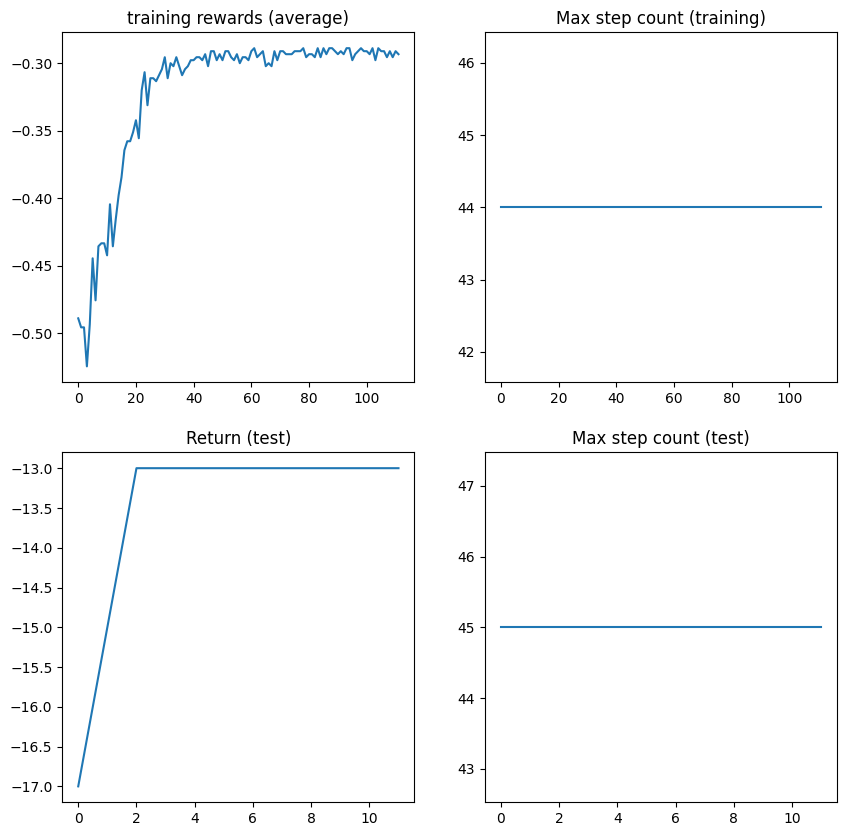

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.plot(logs["reward"])
plt.title("training rewards (average)")
plt.subplot(2, 2, 2)
plt.plot(logs["step_count"])
plt.title("Max step count (training)")
plt.subplot(2, 2, 3)
plt.plot(logs["eval reward (sum)"])
plt.title("Return (test)")
plt.subplot(2, 2, 4)
plt.plot(logs["eval step_count"])
plt.title("Max step count (test)")
plt.show()

# DQN

In [282]:
from torchrl.modules import EGreedyModule, MLP, QValueModule
from tensordict.nn import TensorDictModule, TensorDictSequential
value_mlp = TypeSafeMLP(out_features=env.action_spec.shape[-1], num_cells=[64, 64])
policy = TensorDictSequential(
    TensorDictModule(value_mlp, in_keys=["observation"], out_keys=["action_value"]), 
    QValueModule(spec=env.action_spec, action_mask_key="mask", )
)
exploration_module = EGreedyModule(env.action_spec, annealing_num_steps=10_000, eps_init=0.5, action_mask_key="mask", device=device)
policy_explore = TensorDictSequential(policy, exploration_module)

In [285]:
from torchrl.collectors import SyncDataCollector
from torchrl.data import LazyTensorStorage, ReplayBuffer

init_rand_steps = 5000
frames_per_batch = 1000
optim_steps = 10
collector = SyncDataCollector(
    env,
    policy_explore,
    frames_per_batch=frames_per_batch,
    total_frames=10_000,
    init_random_frames=init_rand_steps,
)
rb = ReplayBuffer(storage=LazyTensorStorage(100_000))

In [284]:
for i, data in enumerate(collector):
    rb.extend(data)
    max_length = rb[:]["next", "step_count"].max()
    print(max_length)

tensor(45)
tensor(45)
tensor(45)


KeyboardInterrupt: 

In [279]:
exploration_module.step(50)

In [286]:
from torchrl.objectives import DQNLoss, SoftUpdate
from torch.optim import Adam
loss = DQNLoss(value_network=policy, action_space=env.action_spec, delay_value=True)
optim = Adam(loss.parameters(), lr=0.02)
updater = SoftUpdate(loss, eps=0.99)

In [27]:
from torchrl._utils import logger as torchrl_logger
import time
total_count = 0
total_episodes = 0
t0 = time.time()
for i, data in enumerate(collector):
    print(collector)
    # Write data in replay buffer
    rb.extend(data)
    max_length = rb[:]["next", "step_count"].max()
    if len(rb) > init_rand_steps:
        # Optim loop (we do several optim steps
        # per batch collected for efficiency)
        for _ in range(optim_steps):
            sample = rb.sample(64)
            loss_vals = loss(sample)
            loss_vals["loss"].backward()
            optim.step()
            optim.zero_grad()
            # Update exploration factor according to the number of steps
            exploration_module.step(data.numel())
            # Update target params
            updater.step()
            if i % 10:
                torchrl_logger.info(f"Max num steps: {max_length}, rb length {len(rb)}")
            total_count += data.numel()
            total_episodes += data["next", "done"].sum()

t1 = time.time()

torchrl_logger.info(
    f"solved after {total_count} steps, {total_episodes} episodes and in {t1-t0}s."
)

2025-06-25 12:10:13,759 [torchrl][INFO] solved after 0 steps, 0 episodes and in 0.00032138824462890625s.
